<a href="https://colab.research.google.com/github/HamzaEric/RNN_Human_Activity_Recognition/blob/main/Notebooks/Vanishing_Gradients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [3]:
ACTIVITY_MAP = {
    0: "WALKING",
    1: "WALKING_UPSTAIRS",
    2: "WALKING_DOWNSTAIRS",
    3: "SITTING",
    4: "STANDING",
    5: "LAYING",
}
NUM_CLASSES = 6


BATCH_SIZE  = 96     # we process 96 sequences in parallel
SEQ_LEN     = 128    # timesteps per window
INPUT_SIZE  = 9      # channels (3 body_acc + 3 total_acc + 3 body_gyro)
HIDDEN_SIZE = 32     # hidden state dimensionality

device = torch.device("cpu")
print("Using device:", device)

Using device: cpu


In [4]:
def load_csv_dataset(train_path="/content/drive/MyDrive/HAR_Processed_Data/har_train_standardized.csv",
                     test_path="/content/drive/MyDrive/HAR_Processed_Data/har_test_standardized.csv",
                     timesteps=128, channels=9):
    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)

    def df_to_arrays(df):
        y = df["label"].values.astype(np.int64)              # (N,)
        subj = df["subject"].values.astype(np.int64)         # (N,)
        X_flat = df.drop(columns=["label","subject"]).values # (N, 1152)
        X = X_flat.reshape(len(df), timesteps, channels)     # (N, 128, 9)
        return X.astype(np.float32), y, subj

    X_train, y_train, subj_train = df_to_arrays(train_df)
    X_test,  y_test,  subj_test  = df_to_arrays(test_df)

    return X_train, y_train, X_test, y_test, subj_train, subj_test

# Load CSVs by default
X_train, y_train, X_test, y_test, subj_train, subj_test = load_csv_dataset()

print("Train shapes:", X_train.shape, y_train.shape, "(expect (N,128,9), (N,))")
print("Test  shapes:", X_test.shape,  y_test.shape)

# Wrap as tensors (batch-first)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),
                          batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

xb, yb = next(iter(train_loader))
print("One training batch:", xb.shape, yb.shape, "(expect (96,128,9), (96,))")


Train shapes: (7352, 128, 9) (7352,) (expect (N,128,9), (N,))
Test  shapes: (2947, 128, 9) (2947,)
One training batch: torch.Size([96, 128, 9]) torch.Size([96]) (expect (96,128,9), (96,))


In [5]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size=9, hidden_size=32, num_classes=6, num_layers=1, nonlinearity="tanh"):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity=nonlinearity,
            batch_first=True,   # expects (B, T, F)
            bidirectional=False
        )
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        x: (B, T, F) = (batch, seq_len, input_size)
        returns:
          logits: (B, C)
          out_seq: (B, T, H)        # hidden states at all timesteps
          h_n: (num_layers, B, H)   # final hidden state(s)
        """
        out_seq, h_n = self.rnn(x)
        last_hidden = out_seq[:, -1, :]        # (B, H)
        logits = self.fc(last_hidden)          # (B, C)
        return logits, out_seq, h_n

In [6]:
model = RNNClassifier(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE,
                      num_classes=NUM_CLASSES, num_layers=1, nonlinearity="tanh").to(device)

ckpt_path = "rnn_har.pth"
state = torch.load(ckpt_path, map_location=device, weights_only=False)
model.load_state_dict(state)
model.eval()

print("Loaded trained weights from:", ckpt_path)

Loaded trained weights from: rnn_har.pth


In [9]:
xb, yb = next(iter(test_loader))
xb = xb.to(device)
yb = yb.to(device)
with torch.no_grad():
    logits, out_seq, h_n = model(xb)

print("xb:", tuple(xb.shape))           # (96, 128, 9)
print("out_seq:", tuple(out_seq.shape)) # (96, 128, 32)
print("h_n:", tuple(h_n.shape))         # (1, 96, 32)
print("logits:", tuple(logits.shape))   # (96, 6)
print("softmax row sum ~1.0:", float(F.softmax(logits, dim=1)[0].sum()))

# Quick overall test accuracy (not per-class; detailed metrics in §4)
def quick_accuracy(model, loader, device="cpu"):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits, _, _ = model(xb)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.numel()
    return correct / total

acc = quick_accuracy(model, test_loader, device=device)
print(f"Quick test accuracy (overall): {acc:.3f}")

xb: (96, 128, 9)
out_seq: (96, 128, 32)
h_n: (1, 96, 32)
logits: (96, 6)
softmax row sum ~1.0: 1.0
Quick test accuracy (overall): 0.848


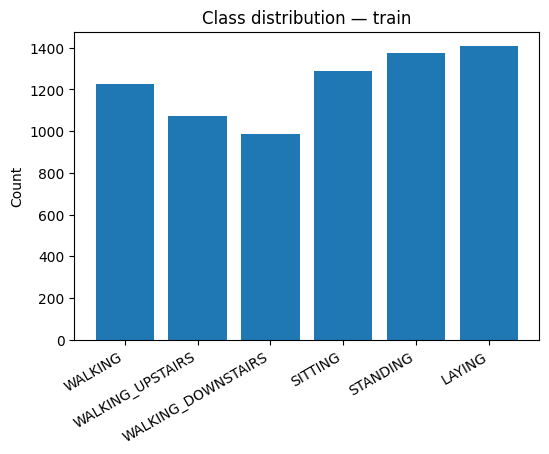

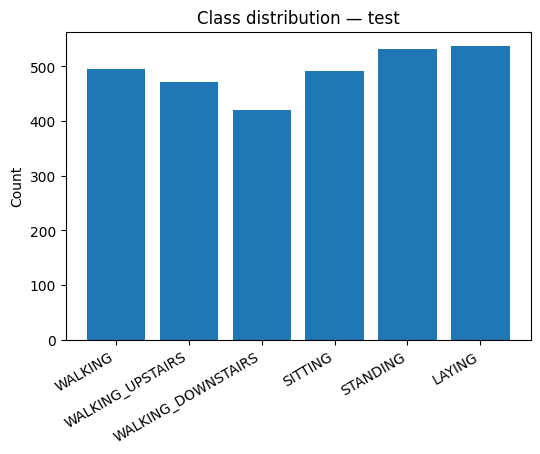

Train counts: [1226 1073  986 1286 1374 1407]
Test counts : [496 471 420 491 532 537]


In [13]:
def plot_class_distribution(y, split="train"):
    counts = np.bincount(y, minlength=NUM_CLASSES)
    plt.figure(figsize=(6,4))
    plt.bar(range(NUM_CLASSES), counts, tick_label=[ACTIVITY_MAP[i] for i in range(NUM_CLASSES)])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Count")
    plt.title(f"Class distribution — {split}")
    plt.show()
    return counts

train_counts = plot_class_distribution(y_train, split="train")
test_counts  = plot_class_distribution(y_test,  split="test")

print("Train counts:", train_counts)
print("Test counts :", test_counts)

### **Vanishing Gradients**

**Theory: Why do gradients vanish?**

When training RNNs, we use **Backpropagation Through Time (BPTT)**:  
- Gradients flow backward through all timesteps (here, 128).  
- At each step, the gradient is multiplied by terms from the chain rule.  

If those terms are **smaller than 1**, the product shrinks **exponentially** with the number of timesteps.  
This leads to the **vanishing gradient problem**:

- Early timesteps contribute almost nothing to the final weight update.  
- The RNN struggles to capture **long-term dependencies**.  
- Training focuses mostly on the most recent steps.  

This is one of the main reasons more advanced architectures (LSTM/GRU) were developed.

In [14]:
model = RNNClassifier(input_size=9, hidden_size=32, num_classes=6, num_layers=1, nonlinearity="tanh")
model.load_state_dict(torch.load("rnn_har.pth", map_location="cpu", weights_only=False))
model.train()

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Take one mini-batch
xb, yb = next(iter(train_loader))

# Forward pass
logits, out_seq, h_n = model(xb)
loss = criterion(logits, yb)

# Backward pass
optimizer.zero_grad()
loss.backward()

# Collect gradient norms
grad_norms = {}
for name, param in model.named_parameters():
    if param.grad is not None:
        grad_norms[name] = param.grad.norm().item()

grad_norms

{'rnn.weight_ih_l0': 0.2792735695838928,
 'rnn.weight_hh_l0': 1.1025722026824951,
 'rnn.bias_ih_l0': 0.2313084602355957,
 'rnn.bias_hh_l0': 0.23130854964256287,
 'fc.weight': 0.06284337490797043,
 'fc.bias': 0.012920606881380081}

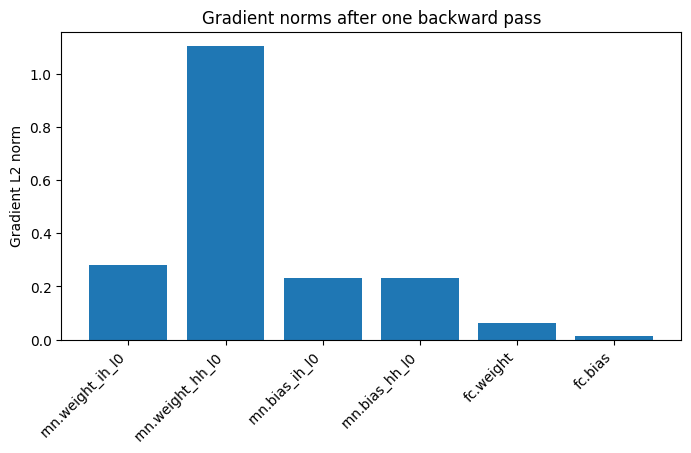

In [15]:
plt.figure(figsize=(8,4))
plt.bar(range(len(grad_norms)), list(grad_norms.values()), tick_label=list(grad_norms.keys()))
plt.ylabel("Gradient L2 norm")
plt.title("Gradient norms after one backward pass")
plt.xticks(rotation=45, ha="right")
plt.show()

First 10 timestep input-grad norms: tensor([0.0036, 0.0019, 0.0011, 0.0008, 0.0008, 0.0009, 0.0009, 0.0010, 0.0014,
        0.0020])


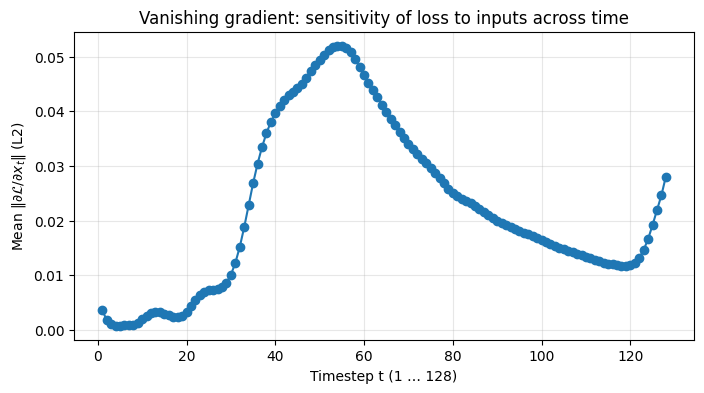

In [16]:
model.train()

xb, yb = next(iter(train_loader))
xb = xb.clone().detach().requires_grad_(True)  # (B, 128, 9) — enable grad on inputs

logits, out_seq, h_n = model(xb)               # loss depends ONLY on last hidden via logits
criterion = torch.nn.CrossEntropyLoss()
loss = criterion(logits, yb)

model.zero_grad()
loss.backward()                                 # single backward pass from t=128

# Gradients wrt inputs: shape (B, T, F). Reduce over batch & channels → (T,)

grad_x = xb.grad.detach()                       # (B, 128, 9)
grad_x_norm_per_t = torch.linalg.vector_norm(grad_x, dim=(0, 2))  # (T,)

print("First 10 timestep input-grad norms:", grad_x_norm_per_t[:10])

T = grad_x_norm_per_t.numel()
plt.figure(figsize=(8,4))
plt.plot(range(1, T+1), grad_x_norm_per_t.numpy(), marker="o")
plt.xlabel("Timestep t (1 … 128)")
plt.ylabel(r"Mean $\|\partial \mathcal{L} / \partial x_t\|$ (L2)")
plt.title("Vanishing gradient: sensitivity of loss to inputs across time")
plt.grid(True, alpha=0.3)
plt.show()

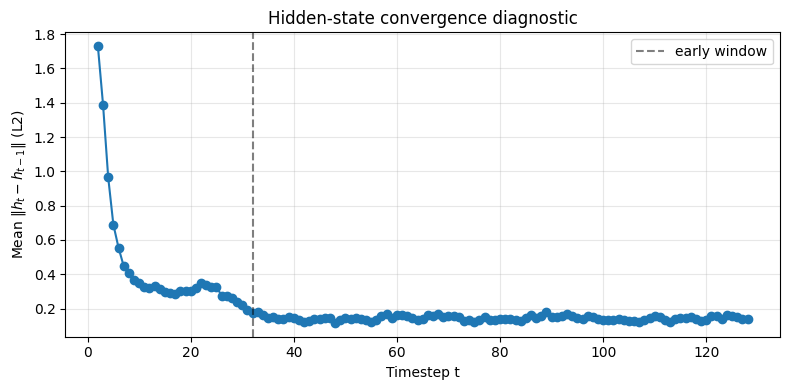

Fraction of early timesteps with near-zero hidden change: 0.00 (threshold ~ 7.45e-03)


In [17]:
# Hidden-state convergence diagnostic: mean ||h_t - h_{t-1}|| over batch
model.eval()
with torch.no_grad():
    xb_eval, _ = next(iter(test_loader))         # (B, T, F)
    logits_eval, out_seq_eval, _ = model(xb_eval)  # out_seq_eval: (B, T, H)

# Step-to-step hidden change: (B, T-1, H) -> mean L2 over batch
delta = out_seq_eval[:, 1:, :] - out_seq_eval[:, :-1, :]
delta_norm_t = torch.linalg.vector_norm(delta, dim=2).mean(dim=0)  # (T-1,)

plt.figure(figsize=(8,4))
plt.plot(range(2, T+1), delta_norm_t.numpy(), marker="o")
plt.axvline(x=(T//4), color="k", ls="--", alpha=0.5, label="early window")
plt.xlabel("Timestep t")
plt.ylabel(r"Mean $\|h_t - h_{t-1}\|$ (L2)")
plt.title("Hidden-state convergence diagnostic")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Quantify early stagnation relative to the distribution of changes
th = float(0.05 * torch.median(delta_norm_t).item()) if delta_norm_t.numel() else 1e-3
early_plateau_frac = float((delta_norm_t[:(T//4 - 1)] < th).float().mean().item()) if T > 4 else 0.0
print(f"Fraction of early timesteps with near-zero hidden change: {early_plateau_frac:.2f} (threshold ~ {th:.2e})")


In [18]:
correct, total = 0, 0
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        logits, _, _ = model(xb)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total   += yb.size(0)

test_acc = correct / total
print(f"Overall Test Accuracy: {test_acc:.3f}")

Overall Test Accuracy: 0.848


In [19]:
model.eval()

all_true = []
all_pred = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits, _, _ = model(xb)             # (B, 6)
        preds = logits.argmax(dim=1)         # (B,)
        all_true.append(yb.cpu().numpy())
        all_pred.append(preds.cpu().numpy())

y_true = np.concatenate(all_true)            # shape (N_test,)
y_pred = np.concatenate(all_pred)            # shape (N_test,)

print("Collected predictions:", y_true.shape, y_pred.shape)

Collected predictions: (2947,) (2947,)


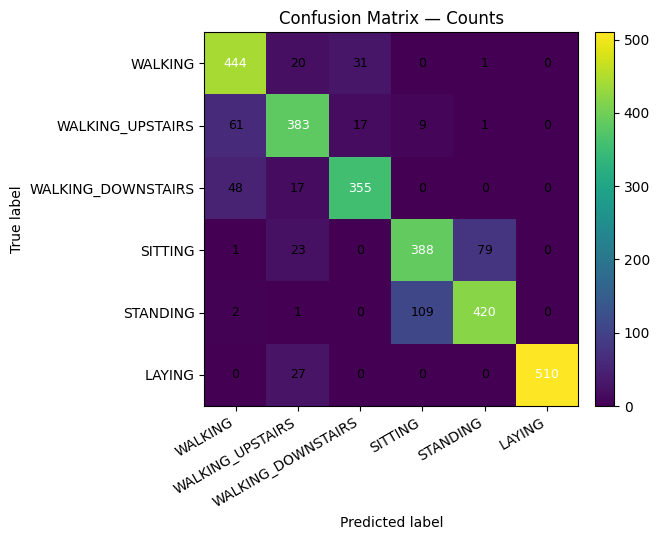

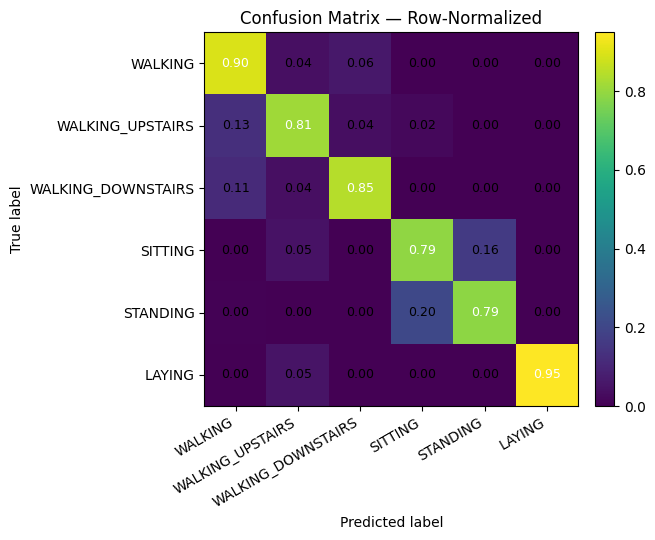

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(ACTIVITY_MAP))))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

def plot_confusion_matrix(matrix, labels, title, normalize=False):
    plt.figure(figsize=(6.5, 5.5))
    im = plt.imshow(matrix, interpolation="nearest")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=30, ha="right")
    plt.yticks(ticks=np.arange(len(labels)), labels=labels)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)

    # Annotate cells
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            if normalize:
                txt = f"{val:.2f}"
            else:
                txt = f"{int(val)}"
            plt.text(j, i, txt, ha="center", va="center", fontsize=9, color="white" if matrix[i,j] > matrix.max()*0.6 else "black")
    plt.tight_layout()
    plt.show()

labels = [ACTIVITY_MAP[i] for i in range(len(ACTIVITY_MAP))]

plot_confusion_matrix(cm, labels, title="Confusion Matrix — Counts", normalize=False)
plot_confusion_matrix(cm_norm, labels, title="Confusion Matrix — Row-Normalized", normalize=True)

# **Reflection on RNN Limitations**

**What we learned about vanilla RNNs**
So far, we’ve seen both strengths and weaknesses:

- **Vanishing gradients**  
  - Our gradient–timestep plots showed that signals from early timesteps contribute almost nothing to the final loss.  
  - This means the RNN struggles to learn dependencies that span **long sequences** (e.g., detecting a subtle pattern at $t=10$ that matters for classification at $t=128$).

- **Limited memory capacity**  
  - The model must compress all 128 timesteps into one final hidden state $h_{128}$.  
  - This "bottleneck" can cause the network to forget fine-grained details about the sequence.

- **Confusions in overlapping/transition activities**  
  - Our per-class analysis showed that similar activities (e.g., WALKING vs. WALKING_UPSTAIRS, SITTING vs. STANDING) are frequently confused.  
  - These cases require the model to **remember context over time**, something vanilla RNNs aren’t good at.

**Motivation for LSTM/GRU**
To overcome these limitations, more advanced recurrent architectures were developed:

- **LSTMs (Long Short-Term Memory)** introduce **gates** (input, forget, output) to control how information flows through time.  
- **GRUs (Gated Recurrent Units)** simplify this with fewer gates, but the same core idea.  
- Both architectures:  
  - Allow **better gradient flow** across long sequences.  
  - Provide a form of **selective memory** — the network can learn what to remember and what to forget.